In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/NehaSharma-26/BankCustomerChurnAnalysis/refs/heads/main/Customer-Churn-Records.csv")

In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


# Bank Customer Churn Analysis

**Business problem:** A bank wants to understand why customers are leaving (churning)
and which customers are at highest risk, so retention efforts can be targeted
instead of blanket offers to everyone.

**Dataset:** 10,000 bank customers across France, Germany, and Spain, with
demographic, account, and engagement details, plus whether they exited (churned).

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [8]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
print("Dataset shape:", df.shape)
print("\nOverall churn rate:")
print((df['Exited'].value_counts(normalize=True) * 100).round(2))

Dataset shape: (10000, 15)

Overall churn rate:
Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


### Key Business Questions Answered

1. **Does location affect churn?** Yes — Germany churns nearly double France/Spain (32.44% vs ~16%).
2. **Does age affect churn?** Yes — churned customers are on average 7+ years older (44.8 vs 37.4).
3. **Does account balance affect churn?** Yes, counterintuitively — customers with money in the account churn almost 2x more than zero-balance customers.
4. **Does number of products affect churn?** Yes, dramatically — the strongest finding in the dataset. Churn jumps from 7.6% (2 products) to 82.7% (3 products) to 100% (4 products).
5. **Does engagement (active membership) affect churn?** Yes — inactive members churn nearly 2x more than active members.
6. **Does customer satisfaction score predict churn?** No — surprisingly, no significant relationship at all (p = 0.43), suggesting the survey isn't capturing real churn drivers.
7. **Can we predict who will churn?** Yes — a Random Forest model catches 72% of actual churners (vs. only 21% for a simpler model), confirming Age, NumOfProducts, and Balance as the top predictive drivers.

## Sample Overview

The dataset covers 10,000 bank customers across France, Germany, and Spain,
with 15 features after removing identifier columns.

**Overall churn rate: 20.38%** — roughly 1 in 5 customers has left the bank.
This is an imbalanced target: a model predicting "no churn" for everyone would
already be ~80% accurate but useless for the business. This is kept in mind
for the modeling stage later, where recall on churned customers matters more
than raw accuracy.

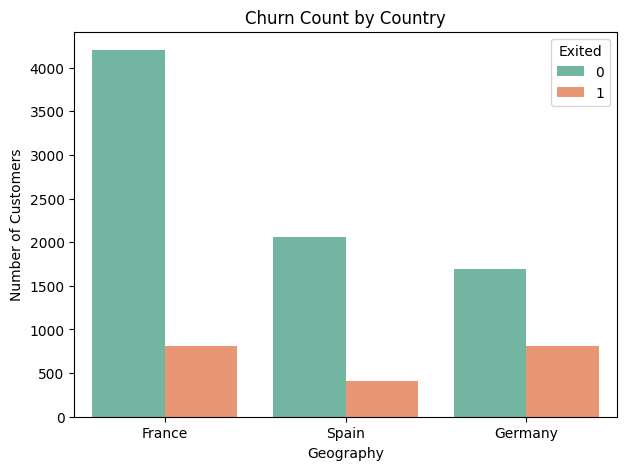

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(x='Geography', hue='Exited', data=df, palette='Set2')
plt.title("Churn Count by Country")
plt.ylabel("Number of Customers")
plt.show()

In [12]:
country_churn_rate = (df.groupby('Geography')['Exited'].mean() * 100).round(2)
print("Churn Rate by Country (%):\n", country_churn_rate)

Churn Rate by Country (%):
 Geography
France     16.17
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64


**Finding:** Germany has a churn rate of 32.44% — nearly double France (16.17%)
and Spain (16.67%) — despite having the smallest customer base of the three
countries. This is the single biggest geographic red flag in the data — investigated further below to see whether it's driven by customer demographics or something specific to the German market.

In [13]:
from scipy.stats import chi2_contingency

geo_churn_table = pd.crosstab(df['Geography'], df['Exited'])
chi2, p, dof, expected = chi2_contingency(geo_churn_table)

print("Chi-square statistic:", round(chi2, 2))
print("p-value:", p)

Chi-square statistic: 300.63
p-value: 5.245736109572763e-66


**Statistical test:** A chi-square test of independence confirms the link
between Geography and churn is statistically significant (χ² = 300.63,
p < 0.001). This isn't random variation — geography is a real driver of
churn in this data, with Germany the clear outlier.

In [14]:
compare_cols = ['Age', 'NumOfProducts', 'IsActiveMember', 'Balance']
germany_vs_others = df.groupby(df['Geography'] == 'Germany')[compare_cols].mean().round(2)
germany_vs_others.index = ['Other Countries', 'Germany']
print(germany_vs_others)

                   Age  NumOfProducts  IsActiveMember    Balance
Other Countries  38.64           1.53            0.52   62001.87
Germany          39.77           1.52            0.50  119730.12


**Why is Germany different?** Comparing Germany to other countries on the
main churn drivers shows Age (39.77 vs 38.64), NumOfProducts (1.52 vs 1.53),
and IsActiveMember (0.50 vs 0.52) are all nearly identical — so Germany's
elevated churn isn't explained by a different customer mix on these factors.

The one striking difference is Balance: German customers hold nearly double
the average balance of customers elsewhere (€119,730 vs €62,001). Combined
with the earlier finding that higher-balance customers churn more overall,
this suggests Germany's high churn rate is largely driven by having a
wealthier customer base that competitor banks are actively targeting —
rather than any dissatisfaction unique to German service quality.

**Revised recommendation:** Retention efforts in Germany should focus
specifically on higher-balance customers with competitive rate-matching or
relationship banking, rather than a broad country-wide intervention.
</br>

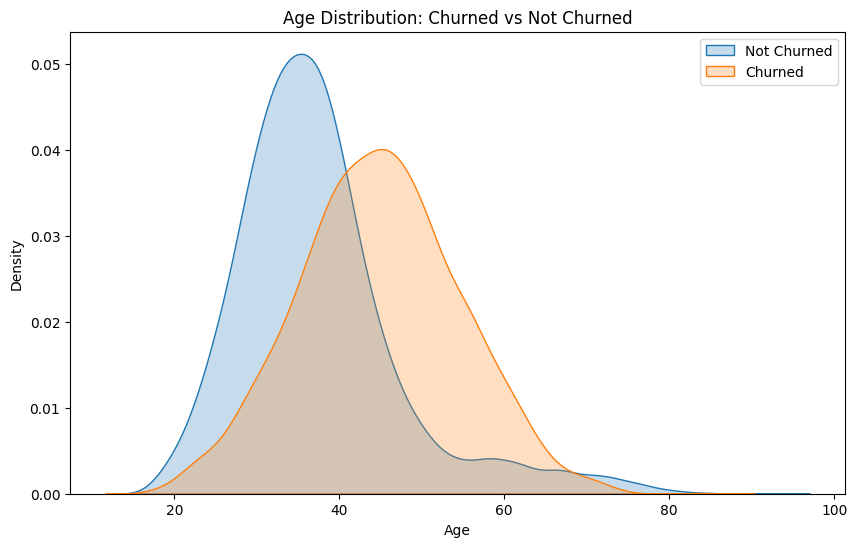

In [15]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df[df['Exited'] == 0]['Age'], label='Not Churned', fill=True)
sns.kdeplot(data=df[df['Exited'] == 1]['Age'], label='Churned', fill=True)
plt.title("Age Distribution: Churned vs Not Churned")
plt.xlabel("Age")
plt.legend()
plt.show()

In [16]:
age_summary = df.groupby('Exited')['Age'].mean().round(1)
print("Average Age by Churn Status:\n", age_summary)

Average Age by Churn Status:
 Exited
0    37.4
1    44.8
Name: Age, dtype: float64


In [17]:
from scipy.stats import mannwhitneyu

churned_age = df[df['Exited'] == 1]['Age']
retained_age = df[df['Exited'] == 0]['Age']

u_stat, p_val = mannwhitneyu(churned_age, retained_age)
print("Mann-Whitney U statistic:", u_stat)
print("p-value:", p_val)

Mann-Whitney U statistic: 11878815.0
p-value: 2.7802649610221583e-230


**Finding:** Churned customers are on average 7.4 years older than retained
customers (44.8 vs 37.4). A Mann-Whitney U test confirms this difference is
highly statistically significant (p < 0.001).

This suggests the bank may be losing older, likely higher-balance customers
— possibly to competitors offering better retirement/wealth products, or due
to declining engagement with digital-first banking features as customers age.

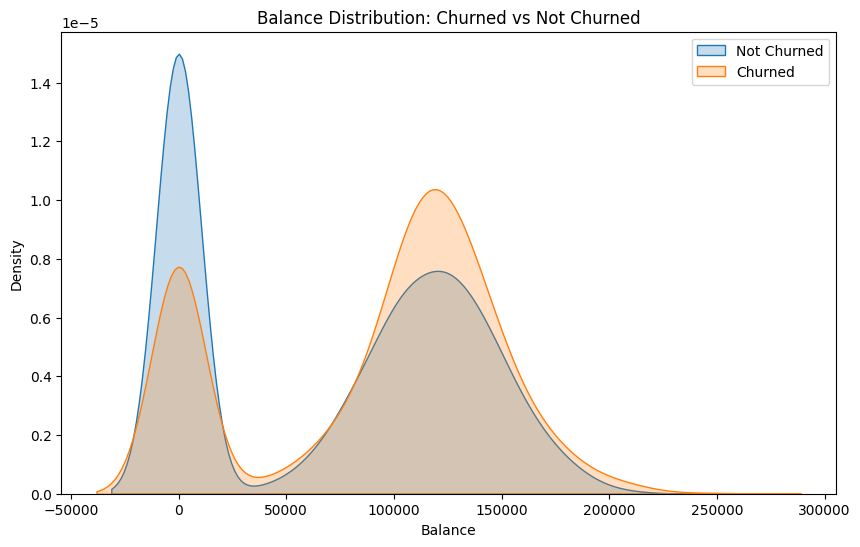

In [18]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df[df['Exited'] == 0]['Balance'], label='Not Churned', fill=True)
sns.kdeplot(data=df[df['Exited'] == 1]['Balance'], label='Churned', fill=True)
plt.title("Balance Distribution: Churned vs Not Churned")
plt.xlabel("Balance")
plt.legend()
plt.show()

In [19]:
balance_summary = df.groupby('Exited')['Balance'].mean().round(2)
print("Average Balance by Churn Status:\n", balance_summary)

zero_balance_churn = df[df['Balance'] == 0]['Exited'].mean() * 100
nonzero_balance_churn = df[df['Balance'] > 0]['Exited'].mean() * 100
print(f"\nChurn rate when Balance = 0: {zero_balance_churn:.2f}%")
print(f"Churn rate when Balance > 0: {nonzero_balance_churn:.2f}%")

Average Balance by Churn Status:
 Exited
0    72742.75
1    91109.48
Name: Balance, dtype: float64

Churn rate when Balance = 0: 13.82%
Churn rate when Balance > 0: 24.10%


In [20]:
churned_balance = df[df['Exited'] == 1]['Balance']
retained_balance = df[df['Exited'] == 0]['Balance']

u_stat, p_val = mannwhitneyu(churned_balance, retained_balance)
print("Mann-Whitney U statistic:", u_stat)
print("p-value:", p_val)

Mann-Whitney U statistic: 9373909.5
p-value: 1.1687654686289807e-28


**Finding:** Customers with a non-zero balance churn almost twice as often as
zero-balance customers (24.10% vs 13.82%), and churned customers carry a higher
average balance overall (€91,109 vs €72,743). A Mann-Whitney U test confirms
this is statistically significant (p < 0.001).

This is counterintuitive at first — you'd expect customers with money in the
bank to be the most loyal. Instead, they appear to be the bank's biggest flight
risk, likely because they're the customers with enough balance to be worth
courting by competitor banks offering better rates or products. Zero-balance
customers may be using the account passively and have less reason to leave
*or* switch.

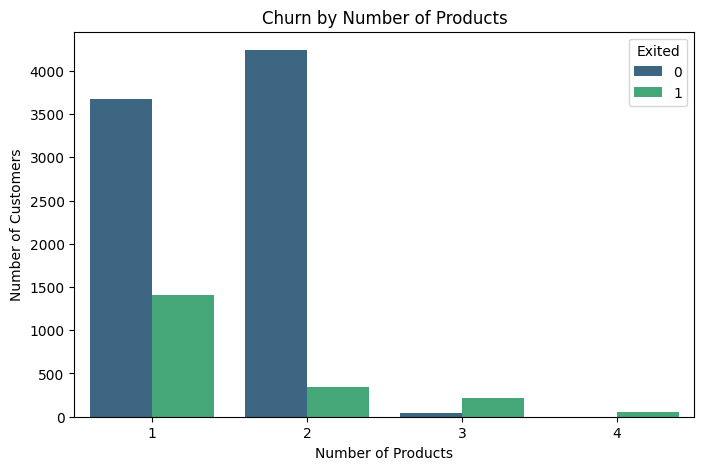

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='viridis')
plt.title("Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")
plt.show()

In [22]:
product_churn_rate = (df.groupby('NumOfProducts')['Exited'].mean() * 100).round(2)
print("Churn Rate by Number of Products (%):\n", product_churn_rate)

Churn Rate by Number of Products (%):
 NumOfProducts
1     27.71
2      7.60
3     82.71
4    100.00
Name: Exited, dtype: float64


In [23]:
product_churn_table = pd.crosstab(df['NumOfProducts'], df['Exited'])
chi2, p, dof, expected = chi2_contingency(product_churn_table)

print("Chi-square statistic:", round(chi2, 2))
print("p-value:", p)

Chi-square statistic: 1501.5
p-value: 0.0


**Finding — the strongest signal in the dataset:** Number of products held is
by far the biggest driver of churn. Customers with 2 products churn the least
(7.60%), but churn jumps sharply to 82.71% at 3 products and 100% at 4 products.
A chi-square test confirms this relationship is highly statistically significant
(χ² = 1501.5, p < 0.001) — the strongest result of any variable tested so far.

This is a major red flag for the bank: customers who end up with 3 or more
products are almost certain to leave. This could point to over-selling
(customers pushed into products they don't want or need), bundling that hurts
the experience, or a product-servicing issue that only shows up once someone
holds multiple accounts. This single finding should likely be the bank's top
retention priority — auditing what happens to customers right after they pick
up a 3rd product.

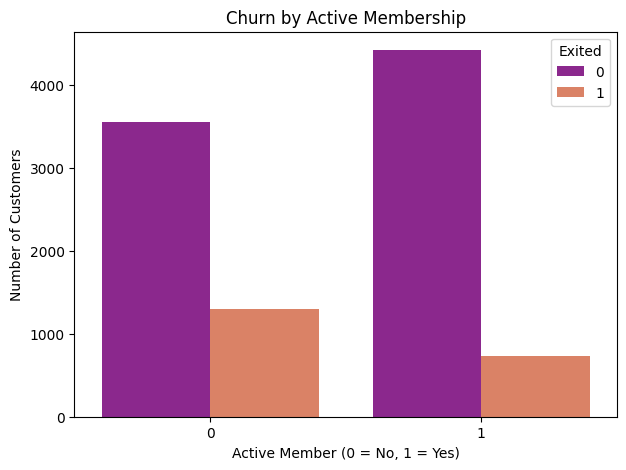

In [24]:
plt.figure(figsize=(7,5))
sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette='plasma')
plt.title("Churn by Active Membership")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

In [25]:
active_churn_rate = (df.groupby('IsActiveMember')['Exited'].mean() * 100).round(2)
print("Churn Rate by Active Membership (%):\n", active_churn_rate)

Churn Rate by Active Membership (%):
 IsActiveMember
0    26.87
1    14.27
Name: Exited, dtype: float64


In [26]:
active_churn_table = pd.crosstab(df['IsActiveMember'], df['Exited'])
chi2, p, dof, expected = chi2_contingency(active_churn_table)

print("Chi-square statistic:", round(chi2, 2))
print("p-value:", p)

Chi-square statistic: 243.69
p-value: 6.153167438113408e-55


**Finding:** Inactive members churn at nearly double the rate of active members
(26.87% vs 14.27%). A chi-square test confirms this is statistically significant
(χ² = 243.69, p < 0.001).

This is one of the more actionable findings: unlike Age or Geography, activity
level is something the bank can directly influence — through re-engagement
campaigns, app nudges, or proactive outreach to customers showing early signs
of inactivity, before they churn.

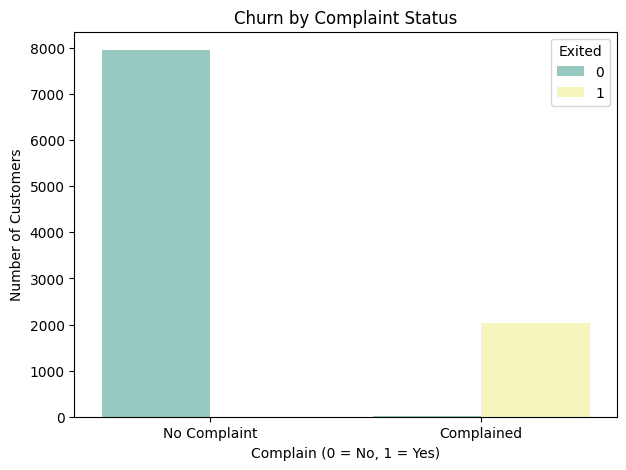

In [27]:
plt.figure(figsize=(7,5))
sns.countplot(x='Complain', hue='Exited', data=df, palette='Set3')
plt.title("Churn by Complaint Status")
plt.xlabel("Complain (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ['No Complaint', 'Complained'])
plt.show()

In [28]:
complain_churn_table = pd.crosstab(df['Complain'], df['Exited'])
print(complain_churn_table)

correlation = df['Complain'].corr(df['Exited'])
print(f"\nCorrelation between Complain and Exited: {correlation:.4f}")

Exited       0     1
Complain            
0         7952     4
1           10  2034

Correlation between Complain and Exited: 0.9957


**Finding — Data Leakage Warning:** `Complain` and `Exited` are correlated at
0.9957 — of 2,044 customers who complained, 2,034 (99.5%) churned. This is
not a normal predictive relationship; it's essentially a duplicate of the
target variable, likely because "Complain" was recorded at or near the point
a customer decided to leave, rather than as an independent early-warning signal.

**Decision:** `Complain` will be excluded from the predictive model later in
this notebook. Including it would produce a model with inflated, meaningless
accuracy (it would just be learning "Complain = 1 → Exited = 1"), which
wouldn't generalize to real early-warning use cases where a customer hasn't
complained yet but is still at risk of leaving.

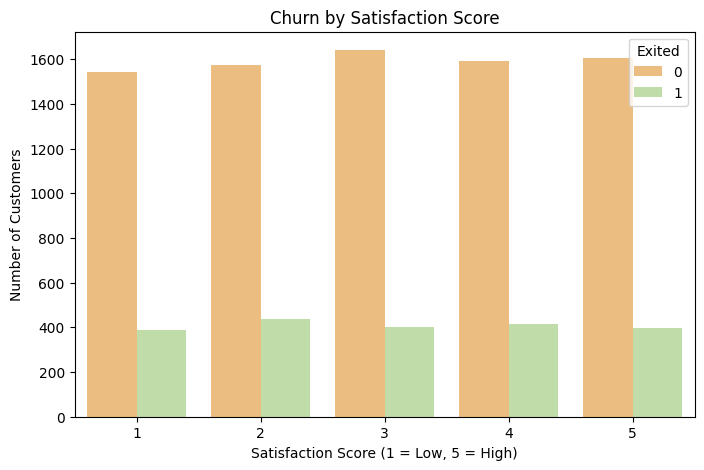

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x='Satisfaction Score', hue='Exited', data=df, palette='Spectral')
plt.title("Churn by Satisfaction Score")
plt.xlabel("Satisfaction Score (1 = Low, 5 = High)")
plt.ylabel("Number of Customers")
plt.show()

In [30]:
satisfaction_churn_rate = (df.groupby('Satisfaction Score')['Exited'].mean() * 100).round(2)
print("Churn Rate by Satisfaction Score (%):\n", satisfaction_churn_rate)

Churn Rate by Satisfaction Score (%):
 Satisfaction Score
1    20.03
2    21.80
3    19.64
4    20.62
5    19.81
Name: Exited, dtype: float64


In [31]:
satisfaction_churn_table = pd.crosstab(df['Satisfaction Score'], df['Exited'])
chi2, p, dof, expected = chi2_contingency(satisfaction_churn_table)

print("Chi-square statistic:", round(chi2, 2))
print("p-value:", p)

Chi-square statistic: 3.8
p-value: 0.43336497327743106


**Finding — No Significant Relationship:** Churn rate is nearly flat across all
satisfaction scores (19.64%–21.80%), and a chi-square test confirms no
statistically significant relationship (χ² = 3.80, p = 0.43).

This is a genuinely useful null result: it suggests the bank's self-reported
satisfaction survey is **not capturing the real drivers of churn**. Customers
who rate themselves highly satisfied churn at almost the same rate as those
who rate themselves dissatisfied. The stronger, more reliable churn signals in
this data are behavioral (Number of Products, Activity Status, Balance) rather
than self-reported sentiment — which is itself worth flagging to the bank as a
survey design issue.

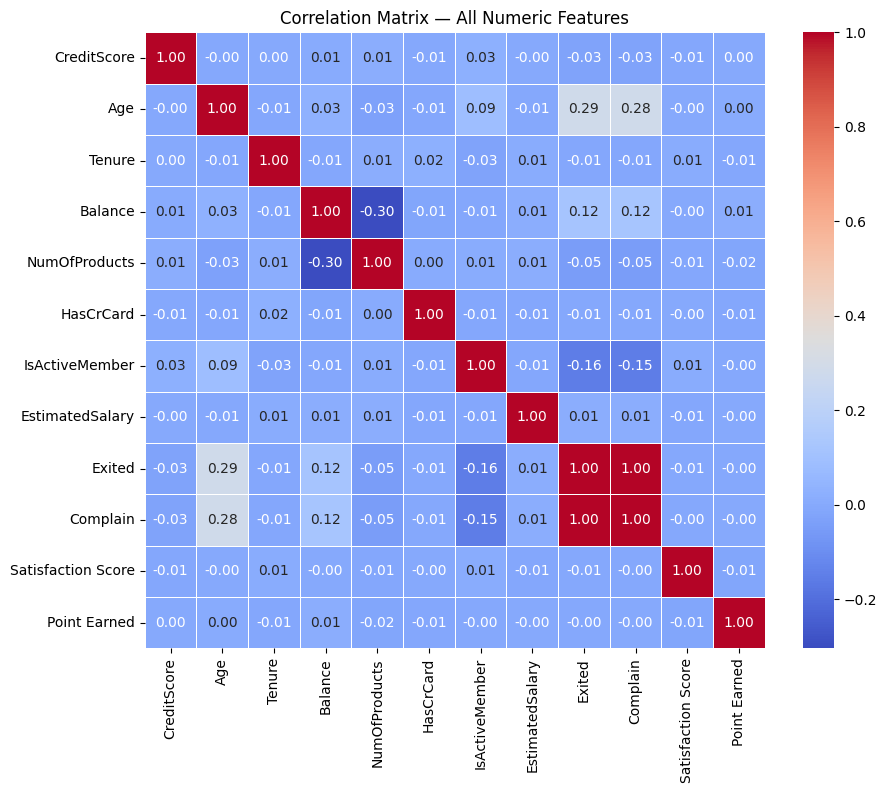

In [32]:
plt.figure(figsize=(10,8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix — All Numeric Features")
plt.show()

**Correlation Matrix — Key Observations:**

- `Complain` shows a 1.00 correlation with `Exited` — visually confirming the
  data leakage flagged earlier. It will be excluded from modeling.
- `Age` (0.29) and `IsActiveMember` (-0.16) are the strongest "normal" linear
  correlates of churn among the remaining features.
- `NumOfProducts` shows almost no linear correlation with `Exited` (-0.05),
  despite being the strongest driver found in the groupby analysis (7.60%
  churn at 2 products vs. 100% at 4 products). This is because the relationship
  is non-linear (U-shaped, not a straight line), which correlation coefficients
  cannot capture. This is a good reminder that correlation alone can hide
  important patterns — categorical breakdowns are still necessary.

In [33]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('churn', conn, index=False, if_exists='replace')

print("Table loaded. Total rows:", pd.read_sql("SELECT COUNT(*) as total FROM churn", conn).iloc[0,0])

Table loaded. Total rows: 10000


## SQL Analysis

The key findings from the Python analysis above are re-verified here using SQL
queries, to demonstrate the same insights can be reached through direct
database querying.

In [34]:
query = """
SELECT Geography,
       COUNT(*) as total_customers,
       SUM(Exited) as churned_customers,
       ROUND(100.0 * SUM(Exited) / COUNT(*), 2) as churn_rate_pct
FROM churn
GROUP BY Geography
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,Geography,total_customers,churned_customers,churn_rate_pct
0,Germany,2509,814,32.44
1,Spain,2477,413,16.67
2,France,5014,811,16.17


**Confirmed:** SQL result matches the earlier pandas groupby exactly —
Germany's churn rate (32.44%) is nearly double France and Spain.

In [35]:
query = """
SELECT NumOfProducts,
       COUNT(*) as total_customers,
       SUM(Exited) as churned_customers,
       ROUND(100.0 * SUM(Exited) / COUNT(*), 2) as churn_rate_pct
FROM churn
GROUP BY NumOfProducts
ORDER BY NumOfProducts
"""
pd.read_sql(query, conn)

,NumOfProducts,total_customers,churned_customers,churn_rate_pct
0,1,5084,1409,27.71
1,2,4590,349,7.60
2,3,266,220,82.71
3,4,60,60,100.00


**Confirmed:** SQL result matches the pandas groupby exactly. The NumOfProducts
finding remains the strongest and clearest pattern in the data — churn jumps
from 7.60% at 2 products to 82.71% at 3 products.

In [36]:
query = """
SELECT IsActiveMember,
       CASE WHEN Balance = 0 THEN 'Zero Balance' ELSE 'Has Balance' END as balance_group,
       COUNT(*) as total_customers,
       ROUND(100.0 * SUM(Exited) / COUNT(*), 2) as churn_rate_pct
FROM churn
GROUP BY IsActiveMember, balance_group
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,IsActiveMember,balance_group,total_customers,churn_rate_pct
0,0,Has Balance,3105,31.66
1,0,Zero Balance,1744,18.35
2,1,Has Balance,3278,16.93
3,1,Zero Balance,1873,9.61


**Finding — Combined Risk Segments:** Combining activity status and balance
reveals a clear risk hierarchy:
- Inactive + has balance: 31.66% churn (highest risk)
- Inactive + zero balance: 18.35% churn
- Active + has balance: 16.93% churn
- Active + zero balance: 9.61% churn (lowest risk)

Inactive customers who are still holding a balance are the bank's single
highest-risk combined segment — over 3x more likely to churn than active,
zero-balance customers. This suggests a good starting point for a targeted
retention campaign: inactive customers with money still in their account.

In [37]:
query = """
SELECT Complain,
       COUNT(*) as total_customers,
       SUM(Exited) as churned_customers,
       ROUND(100.0 * SUM(Exited) / COUNT(*), 2) as churn_rate_pct
FROM churn
GROUP BY Complain
"""
pd.read_sql(query, conn)

,Complain,total_customers,churned_customers,churn_rate_pct
0,0,7956,4,0.05
1,1,2044,2034,99.51


**Confirmed:** SQL matches the Python correlation finding — `Complain` is
essentially a duplicate of `Exited` (99.51% of complainers churned). This is
excluded from the predictive model for the same reason noted earlier.

## Predictive Modeling

We now build a model to predict which customers are likely to churn. `Complain`
is excluded from the features, since it was found to be a near-duplicate of the
target (leakage) rather than a genuine early-warning signal. The goal is a
model useful for identifying at-risk customers *before* they complain or leave.

In [38]:
model_df = df.drop(columns=['Complain'])

model_df = pd.get_dummies(model_df, columns=['Geography', 'Gender', 'Card Type'], drop_first=True)

X = model_df.drop(columns=['Exited'])
y = model_df['Exited']

print("Feature columns:", X.columns.tolist())
print("Shape of X:", X.shape)

Feature columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']
Shape of X: (10000, 16)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nChurn rate in train:", round(y_train.mean()*100, 2), "%")
print("Churn rate in test:", round(y_test.mean()*100, 2), "%")

Training set size: 8000
Test set size: 2000

Churn rate in train: 20.38 %
Churn rate in test: 20.4 %


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Example - Balance before vs after (first 5 rows):")
print(X_train['Balance'].head().values)
print(X_train_scaled[:5, X_train.columns.get_loc('Balance')])

Scaling done. Example - Balance before vs after (first 5 rows):
[     0.    43504.42 145578.28 105957.44      0.  ]
[-1.22695683 -0.52869962  1.10961227  0.47368753 -1.22695683]


In [41]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [42]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.62      0.21      0.32       408

    accuracy                           0.81      2000
   macro avg       0.73      0.59      0.60      2000
weighted avg       0.79      0.81      0.77      2000

Confusion Matrix:
[[1540   52]
 [ 322   86]]

ROC-AUC Score: 0.7784


**Logistic Regression Results:** The model achieves 81% overall accuracy, but
this is misleading given the 80/20 class imbalance. The recall for churned
customers is only 0.21 — the model misses nearly 4 out of 5 actual churners,
which defeats the purpose of an early-warning system. ROC-AUC of 0.78 shows
there is real signal in the data, but logistic regression's straight-line
decision boundary struggles with the non-linear patterns we found earlier
(e.g., the U-shaped NumOfProducts effect). A tree-based model, which can
naturally capture non-linear splits, is tested next.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42, class_weight='balanced'
)
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [44]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_rf), 4))

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.92      0.85      0.89      1592
           1       0.55      0.72      0.62       408

    accuracy                           0.82      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.82      0.83      2000

Confusion Matrix:
[[1357  235]
 [ 116  292]]

ROC-AUC Score: 0.8731


**Model Comparison:**

| Metric              | Logistic Regression | Random Forest |
|----------------------|---------------------|----------------|
| Accuracy             | 0.81                | 0.82           |
| Recall (Churn)       | 0.21                | 0.72           |
| Precision (Churn)    | 0.62                | 0.55           |
| ROC-AUC              | 0.78                | 0.87           |

Random Forest is the clear choice for this use case. While overall accuracy is
similar, Random Forest catches 72% of actual churners versus only 21% for
logistic regression — a far more useful early-warning system for a retention
team, since missing a real churner is more costly to the bank than a false
alarm. The improvement also confirms what the EDA suggested: churn drivers
like NumOfProducts follow non-linear patterns that a tree-based model can
capture but a straight-line model like logistic regression cannot.

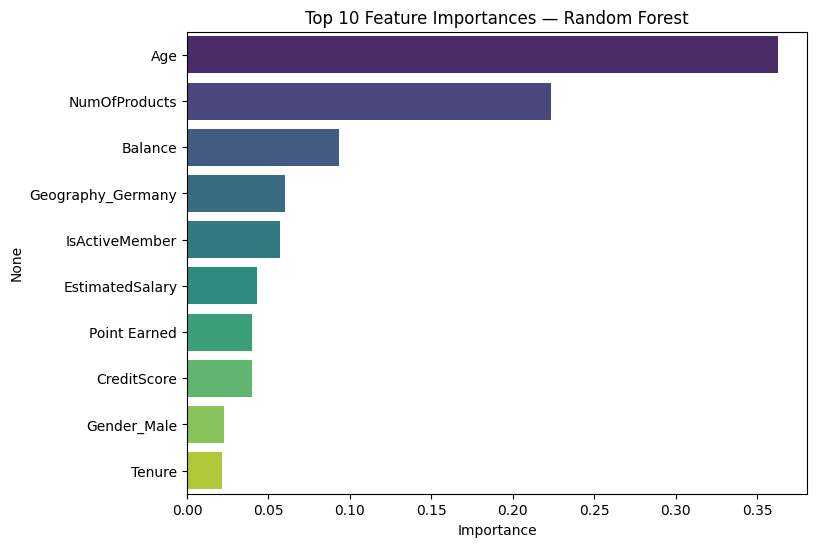

In [45]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], hue=importances.index[:10], palette='viridis', legend=False)
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.show()

**Feature Importance — Random Forest:** The model independently identifies
Age, NumOfProducts, and Balance as the top three drivers of churn — matching
exactly what the manual EDA found earlier. This cross-validation between two
completely different methods (groupby statistics and a machine learning model)
strengthens confidence that these are genuine business drivers, not artifacts
of one particular analysis technique.

Geography_Germany also appears in the top 5, confirming Germany's elevated
churn risk holds up even after accounting for all other factors simultaneously
— it's not just explained away by, say, Germany happening to have older
customers.

## Business Recommendations

Based on the EDA, statistical tests, and the Random Forest model, here are
concrete, prioritized actions for the bank:

1. **Audit the 3rd-product sign-up process (highest priority).** Customers
   with 3 products churn at 82.71%, and 100% with 4 products, versus just
   7.60% at 2 products. Investigate what happens right after a customer picks
   up a 3rd product — likely over-selling, poor onboarding, or bundling issues
   — since this is the single strongest churn signal in the data.

2. **Focus Germany retention on high-balance customers, not a broad regional fix.** Germany's churn rate (32.44%) is nearly double France/Spain, but this isn't explained by age, product count, or activity differences — German customers simply hold nearly double the average balance (€119,730 vs €62,001). This points to a targeted fix: competitive rate-matching or relationship banking for high-balance German customers, rather than a generic country-wide service review.

3. **Target inactive customers who still hold a balance.** This combined
   segment churns at 31.66%, the highest of any group tested — over 3x the
   rate of active, zero-balance customers. This is a clear, actionable list
   for a re-engagement campaign (app nudges, relationship manager outreach).

4. **Re-evaluate the customer satisfaction survey.** Satisfaction score showed
   no significant relationship with churn (p = 0.43). The survey may not be
   capturing the real reasons customers leave — behavioral signals (activity,
   product count, balance) are far more predictive than self-reported
   sentiment.

5. **Deploy the Random Forest model as an early-warning system**, using
   `predict_proba` to score customers monthly and flag the top-risk segment
   for proactive retention outreach — rather than waiting for a formal
   complaint, by which point (per the Complain analysis) it's usually too
   late.

In [46]:
df.to_csv('cleaned_BankChurn.csv', index=False)
print("Saved cleaned_BankChurn.csv — ready for Power BI")

Saved cleaned_BankChurn.csv — ready for Power BI
